In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score, auc, roc_curve
import matplotlib.pyplot as plt

In [2]:
valid_labels = pd.read_csv('../../../results/translation_efficiency/training_data/2_bin/valid.tsv', sep='\t')
test_labels = pd.read_csv('../../../results/translation_efficiency/training_data/2_bin/test.tsv', sep='\t')

In [3]:
model_dict = [
    ('pcv2_1', 'pcv2-l24-d0768'),
    ('pcv2_2', 'pcv2-l48-d1024'),
    ('pcv2_3', 'pcv2-l48-d1536'),
    ('agront', 'agront'),
    ('sup_pcv2_1', 'sup_pcv2-l24-d0768'),
    ('cnn_lstm', 'cnn_lstm'),
]

In [4]:
for model in model_dict:
    curPATH = f'../../../results/translation_efficiency/training_data/2_bin/models/{model[1]}/valid_predictions.tsv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    valid_labels[f'{model[0]}'] = curPreds['probability_positive']

In [5]:
for model in model_dict:
    curPATH = f'../../../results/translation_efficiency/training_data/2_bin/models/{model[1]}/predictions.tsv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    test_labels[f'{model[0]}'] = curPreds['probability_positive']

In [6]:
records = []
pcv2_alphas = [0.4, 0.7, 1.0]
for k, model in enumerate(model_dict):
    valid_preds = valid_labels[f'{model[0]}']
    test_preds = test_labels[f'{model[0]}']

    valid_true = valid_labels['label']
    test_true = test_labels['label']
    
    fpr, tpr, thresholds = roc_curve(valid_true, valid_preds)
    auc_valid = auc(fpr, tpr)
    ap_valid = average_precision_score(valid_true, valid_preds)
    
    fpr, tpr, thresholds = roc_curve(test_true, test_preds)
    auc_test = auc(fpr, tpr)
    ap_test = average_precision_score(test_true, test_preds)

    if 'agront' in model[0].lower():
        color, alpha = 'gray', 1.0
    elif 'sup_pcv2' in model[0].lower():
        color, alpha = 'C1', 1.0
    elif 'cnn' in model[0].lower():
        color, alpha = 'C1', 0.5
    else:
        color, alpha = 'C0', pcv2_alphas[k]

    if 'cnn' in model[0].lower():
        lab = model[0].replace('-imbalance-lr-1e-3', '')
    else:
        lab = model[0].replace('', '')

    records.append({
        'model': model[0],
        'label': 'valid',
        'ap': ap_valid,
        'auc': auc_valid,
        'color': color,
        'alpha': alpha,
        'baseline': valid_true.mean()
    })
    records.append({
        'model': model[0],
        'label': 'test',
        'ap': ap_test,
        'auc': auc_test,
        'color': color,
        'alpha': alpha,
        'baseline': test_true.mean()
    })

In [7]:
df = pd.DataFrame(records)

In [8]:
df

,model,label,ap,auc,color,alpha,baseline
0,pcv2_1,valid,0.833424,0.749803,C0,0.4,0.642935
1,pcv2_1,test,0.566012,0.654990,C0,0.4,0.414116
2,pcv2_2,valid,0.639315,0.496437,C0,0.7,0.642935
3,pcv2_2,test,0.400377,0.490911,C0,0.7,0.414116
4,pcv2_3,valid,0.861162,0.790244,C0,1.0,0.642935
5,pcv2_3,test,0.599968,0.691699,C0,1.0,0.414116
6,agront,valid,0.797257,0.689768,gray,1.0,0.642935
7,agront,test,0.500069,0.586845,gray,1.0,0.414116
8,sup_pcv2_1,valid,0.768592,0.661578,C1,1.0,0.642935
9,sup_pcv2_1,test,0.451240,0.555239,C1,1.0,0.414116


In [9]:
df.to_csv('auc_te-bin.tsv', sep='\t', index=False)

In [10]:
models = df['model'].unique()
n_models = len(models)

species_order = ['valid', 'test']
n_sp = len(species_order)

bar_w = 0.8 / n_models
x = np.arange(n_sp)

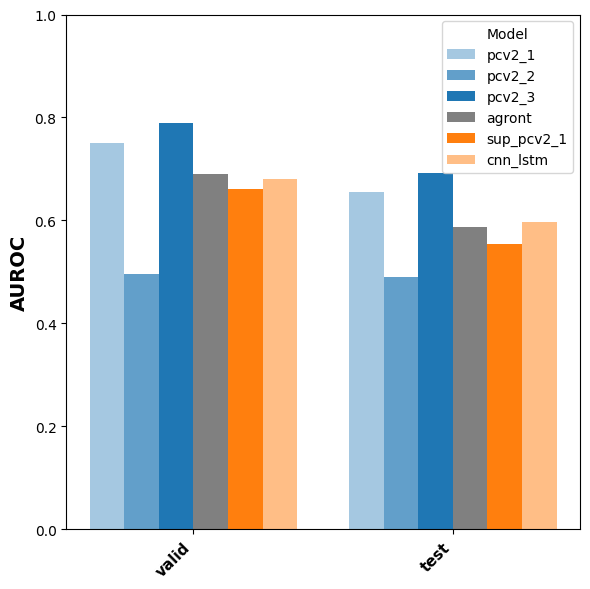

In [11]:
fig, ax = plt.subplots(figsize=(5 + 0.5 * n_sp, 6))

for i, model in enumerate(models):
    sub = df[df['model'] == model]
    sub = sub.set_index('label').reindex(species_order).reset_index()

    ax.bar(
        x + i * bar_w,
        sub['auc'],
        bar_w,
        label=model,
        color=sub['color'].iloc[0] if not sub.empty else 'gray',
        alpha=sub['alpha'].iloc[0] if not sub.empty else 0.5
    )

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(species_order, rotation=45, ha='right', fontsize=11, fontweight='bold')

ax.set_ylabel('AUROC', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(title='Model', fontsize=10)

plt.tight_layout()
plt.savefig('auc_te-bin.pdf', format='pdf', bbox_inches='tight')
plt.show()